In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, log_loss, brier_score_loss,
                               classification_report, confusion_matrix,
                               roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt

In [10]:
# 1. Load data
train = pd.read_csv('train.csv')
X = train.drop(columns=['client_id', 'default'])
y = train['default']

In [11]:
# FEATURE ENGINEERING
# Add derived features that are usually more predictive than raw values
# for this dataset (credit utilization, payment behavior, trends).

def add_engineered_features(df):
    df = df.copy()
    bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
    pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
    pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

    # Credit utilization ratio per month (bill / limit)
    for i, col in enumerate(bill_cols, start=1):
        df[f'UTIL{i}'] = df[col] / df['LIMIT_BAL'].replace(0, np.nan)
    df['UTIL_AVG'] = df[[f'UTIL{i}' for i in range(1, 7)]].mean(axis=1)

    # Payment ratio: how much of the previous bill was actually paid
    # PAY_AMT_i pays down BILL_AMT_{i+1} (i.e. paid in month i, appears against bill i+1's prior balance)
    for i in range(1, 6):
        bill_prior = df[f'BILL_AMT{i+1}'].replace(0, np.nan)
        df[f'PAY_RATIO{i}'] = df[f'PAY_AMT{i}'] / bill_prior
    df['PAY_RATIO_AVG'] = df[[f'PAY_RATIO{i}' for i in range(1, 6)]].mean(axis=1)

    # Delinquency summary stats across the 6 months of payment status
    df['PAY_STATUS_MAX'] = df[pay_status_cols].max(axis=1)
    df['PAY_STATUS_MEAN'] = df[pay_status_cols].mean(axis=1)
    df['MONTHS_DELINQUENT'] = (df[pay_status_cols] > 0).sum(axis=1)

    # Trend: is the bill amount growing or shrinking over the 6 months?
    df['BILL_TREND'] = df['BILL_AMT1'] - df['BILL_AMT6']

    # Clean up inf/nan created by division (e.g. LIMIT_BAL or bill = 0)
    new_cols = ([f'UTIL{i}' for i in range(1, 7)] + ['UTIL_AVG'] +
                [f'PAY_RATIO{i}' for i in range(1, 6)] + ['PAY_RATIO_AVG'] +
                ['PAY_STATUS_MAX', 'PAY_STATUS_MEAN', 'MONTHS_DELINQUENT', 'BILL_TREND'])
    df[new_cols] = df[new_cols].replace([np.inf, -np.inf], np.nan)
    df[new_cols] = df[new_cols].fillna(df[new_cols].median())

    return df

X = add_engineered_features(X)

engineered_cols = ([f'UTIL{i}' for i in range(1, 7)] + ['UTIL_AVG'] +
                    [f'PAY_RATIO{i}' for i in range(1, 6)] + ['PAY_RATIO_AVG'] +
                    ['PAY_STATUS_MAX', 'PAY_STATUS_MEAN', 'MONTHS_DELINQUENT', 'BILL_TREND'])

print(f"Added {len(engineered_cols)} engineered features")
print(X[engineered_cols].describe().T[['mean', 'std', 'min', 'max']])

Added 17 engineered features
                           mean           std            min            max
UTIL1                  0.423783      0.412399      -0.551933       6.455300
UTIL2                  0.411058      0.405323      -1.395540       6.380500
UTIL3                  0.391651      0.398645      -1.025100      10.688575
UTIL4                  0.358722      0.369144      -1.374500       5.146850
UTIL5                  0.332406      0.350522      -0.876743       4.935500
UTIL6                  0.317520      0.345927      -1.509530       3.885550
UTIL_AVG               0.372523      0.352495      -0.232590       5.364308
PAY_RATIO1             0.507817     28.722606    -111.111111    4444.333333
PAY_RATIO2             0.725923     43.261229    -168.242017    5001.000000
PAY_RATIO3            -3.069370    531.194258  -82150.000000    4444.333333
PAY_RATIO4            -0.173292     41.086693   -4306.666667     129.705128
PAY_RATIO5             0.317297      3.552846    -185.33333

In [12]:
# TRAIN/VALIDATION SPLIT
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Default rate — train: {y_train.mean():.3f}, val: {y_val.mean():.3f}")

Train: (19200, 40), Val: (4800, 40)
Default rate — train: 0.221, val: 0.221


In [13]:
#Feature Groups
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']       # nominal -> one-hot
ordinal_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']  # treat as numeric (already ordered ints)
numerical_cols = ['LIMIT_BAL', 'AGE',
                   'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                   'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'] + engineered_cols

# Logistic regression needs scaled numeric features + one-hot categoricals
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols + ordinal_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

In [14]:
#MODEL PIPELINE
logreg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

logreg.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['LIMIT_BAL', 'AGE',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6',
                                                   'UTIL1', 'UTIL2', 'UTIL3',
                                                   'UTIL4', 'UTIL5', 'UTIL6',
                                                   'UTIL_AVG', 'PAY_RATIO1',
                                                   'PAY_RATIO2', 'PAY_RATIO3',
                                                   'PAY_RATIO4', 'PAY_RATIO5',
                                                   'PAY_RATIO_AVG',
                                                   'PAY_STATUS_MAX',
                                                   'PAY_STATUS_MEAN',
                                                   'MONTHS_DELINQUENT', ...]),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['SEX', 'EDUCATION',
                                                   'MARRIAGE'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear']  # supports both l1 and l2
}
grid = GridSearchCV(logreg, param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best CV AUC: {grid.best_score_:.4f}")
print(f"Best params: {grid.best_params_}")

logreg = grid.best_estimator_

Best CV AUC: 0.7591
Best params: {'clf__C': 100, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}


In [16]:
val_proba = logreg.predict_proba(X_val)[:, 1]   # probability of default
val_pred = logreg.predict(X_val)                 # default 0.5 threshold

In [17]:
print("\n=== Ranking & Calibration ===")
print(f"AUC-ROC:     {roc_auc_score(y_val, val_proba):.4f}")
print(f"Log Loss:    {log_loss(y_val, val_proba):.4f}")
print(f"Brier Score: {brier_score_loss(y_val, val_proba):.4f}")

print("\n=== Classification Report (threshold=0.5) ===")
print(classification_report(y_val, val_pred, target_names=['No Default', 'Default']))

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_val, val_pred)
print(cm)
print(f"(rows=actual, cols=predicted; order: No Default, Default)")


=== Ranking & Calibration ===
AUC-ROC:     0.7566
Log Loss:    0.5814
Brier Score: 0.1935

=== Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

  No Default       0.88      0.78      0.83      3738
     Default       0.45      0.62      0.52      1062

    accuracy                           0.75      4800
   macro avg       0.66      0.70      0.67      4800
weighted avg       0.78      0.75      0.76      4800


=== Confusion Matrix ===
[[2924  814]
 [ 408  654]]
(rows=actual, cols=predicted; order: No Default, Default)


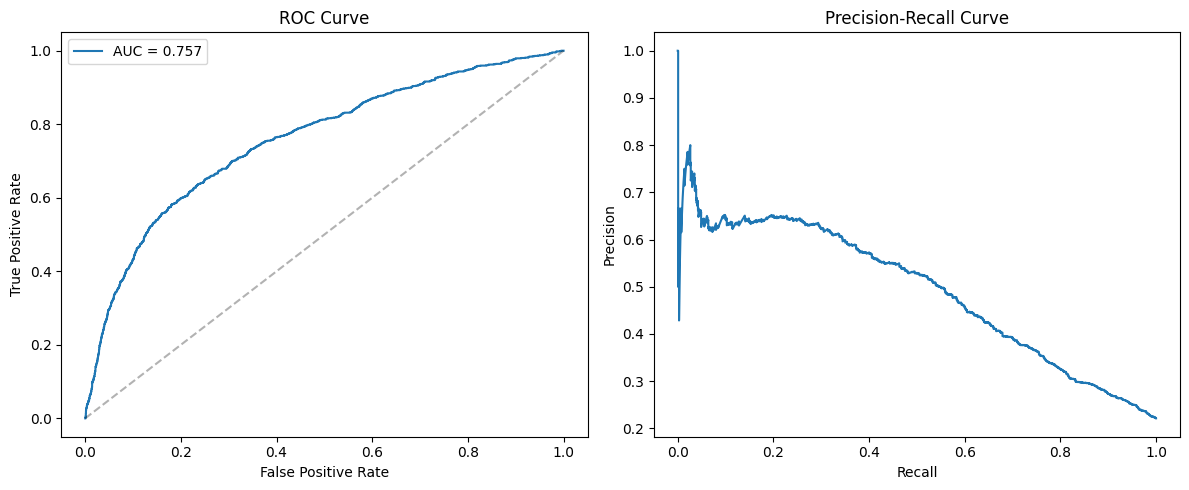

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_val, val_proba)
axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_val, val_proba):.3f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_val, val_proba)
axes[1].plot(rec, prec)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

In [19]:
feature_names = (numerical_cols + ordinal_cols +
                  list(logreg.named_steps['preprocess']
                       .named_transformers_['cat']
                       .get_feature_names_out(categorical_cols)))

coefs = pd.DataFrame({
    'feature': feature_names,
    'coefficient': logreg.named_steps['clf'].coef_[0]
}).sort_values('coefficient', ascending=False)

print("\n=== Top features increasing default risk ===")
print(coefs.head(10))
print("\n=== Top features decreasing default risk ===")
print(coefs.tail(10))


=== Top features increasing default risk ===
        feature  coefficient
23   PAY_RATIO3     5.386939
39  EDUCATION_2     2.677671
40  EDUCATION_3     2.659905
38  EDUCATION_1     2.645273
43  EDUCATION_6     2.617940
41  EDUCATION_4     1.696989
42  EDUCATION_5     1.669767
46   MARRIAGE_3     1.465742
44   MARRIAGE_1     1.430959
45   MARRIAGE_2     1.276075

=== Top features decreasing default risk ===
          feature  coefficient
34          PAY_4    -0.120109
32          PAY_2    -0.126842
37          SEX_2    -0.130243
33          PAY_3    -0.131046
36          PAY_6    -0.132392
9        PAY_AMT2    -0.144100
14          UTIL1    -0.167277
8        PAY_AMT1    -0.198949
0       LIMIT_BAL    -0.200102
26  PAY_RATIO_AVG    -2.886599
